In [1]:
import os
# Fix OpenBLAS thread limit issue
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"

import umap
import numpy as np
import pandas as pd

embeddings_path = "/home/hungdx/code/Lightning-hydra/logs/wildspoof_eval_embs/XLSR_ConformerTCM_spoofceleb_clean_ft_new_noise_and_vocoded_Nov16"

protocol_path = "/home/hungdx/code/Lightning-hydra/data/WildSpoof_Final_Eval/Final_eval/protocol.txt"

protocol_df = pd.read_csv(protocol_path, sep=" ", header=None, names=["utt_id", "subset", "label"])

# If label is spoof then set it to unknown
protocol_df.loc[protocol_df['label'] == 'spoof', 'label'] = 'unknown'
protocol_df['utt_id'] = protocol_df['utt_id'].str.replace('data_v2.0/', '')
protocol_df['utt_id'] = protocol_df['utt_id'].str.replace('.flac', '')
protocol_df

protocol_df



/home/hungdx/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,utt_id,subset,label
0,UTT_00000010,eval,unknown
1,UTT_00000011,eval,unknown
2,UTT_00000012,eval,unknown
3,UTT_00000017,eval,unknown
4,UTT_00000025,eval,unknown
...,...,...,...
102116,UTT_00999943,eval,unknown
102117,UTT_00999952,eval,unknown
102118,UTT_00999954,eval,bonafide
102119,UTT_00999955,eval,unknown


In [2]:
# OPTIMIZED: Load embeddings and match with protocol
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time
from pathlib import Path

print("🚀 Starting optimized embedding loading...")
start_time = time.time()

# Get all .npy files efficiently using pathlib
embedding_files = list(Path(embeddings_path).glob('*.npy'))
print(f"Found {len(embedding_files)} embedding files")

# Pre-allocate lists for better memory efficiency
utt_ids = []
embeddings_list = []

# Load embeddings with progress indication
print("Loading embeddings...")
for i, file_path in enumerate(embedding_files):
    if i % 10000 == 0:  # Progress indicator
        print(f"  Processed {i}/{len(embedding_files)} files...")
    
    utt_id = file_path.stem  # More efficient than string replace
    utt_ids.append(utt_id)
    
    # Load embedding
    emb = np.load(file_path)
    embeddings_list.append(emb)

# Convert to numpy array efficiently
embeddings = np.array(embeddings_list)
load_time = time.time()
print(f"✅ Loaded {len(embeddings)} embeddings with shape: {embeddings.shape}")
print(f"   Loading time: {load_time - start_time:.2f} seconds")

# Create dataframe with embeddings and utterance IDs
emb_df = pd.DataFrame({'utt_id': utt_ids})

# Merge with protocol to get labels
data_df = emb_df.merge(protocol_df, on='utt_id', how='inner')
print(f"Matched {len(data_df)} utterances with protocol")
print(f"Label distribution:\n{data_df['label'].value_counts()}")

data_df.head()


🚀 Starting optimized embedding loading...
Found 102121 embedding files
Loading embeddings...
  Processed 0/102121 files...
  Processed 10000/102121 files...
  Processed 20000/102121 files...
  Processed 30000/102121 files...
  Processed 40000/102121 files...
  Processed 50000/102121 files...
  Processed 60000/102121 files...
  Processed 70000/102121 files...
  Processed 80000/102121 files...
  Processed 90000/102121 files...
  Processed 100000/102121 files...
✅ Loaded 102121 embeddings with shape: (102121, 144)
   Loading time: 39.83 seconds
Matched 102121 utterances with protocol
Label distribution:
label
unknown     91502
bonafide    10619
Name: count, dtype: int64


,utt_id,subset,label
0,UTT_00023726,eval,unknown
1,UTT_00990628,eval,unknown
2,UTT_00333960,eval,unknown
3,UTT_00329303,eval,unknown
4,UTT_00608777,eval,unknown


In [3]:
# Merge with protocol to get labels
data_df = emb_df.merge(protocol_df, on='utt_id', how='inner')
print(f"Matched {len(data_df)} utterances with protocol")
print(f"Label distribution:\n{data_df['label'].value_counts()}")

data_df.head()

Matched 102121 utterances with protocol
Label distribution:
label
unknown     91502
bonafide    10619
Name: count, dtype: int64


,utt_id,subset,label
0,UTT_00023726,eval,unknown
1,UTT_00990628,eval,unknown
2,UTT_00333960,eval,unknown
3,UTT_00329303,eval,unknown
4,UTT_00608777,eval,unknown


In [4]:
# OPTIMIZED: Filter embeddings to match the protocol data using vectorized operations
import time
start_time = time.time()

print("Optimizing data matching with vectorized operations...")

# Create embedding dataframe for efficient merging
emb_df_full = pd.DataFrame({
    'utt_id': utt_ids,
    'emb_idx': range(len(utt_ids))
})

# Use efficient pandas merge instead of nested loops (O(n log n) vs O(n²))
merged_df = emb_df_full.merge(data_df[['utt_id', 'label']], on='utt_id', how='inner')

# Extract matched indices and labels in vectorized way
matched_indices = merged_df['emb_idx'].values
matched_labels = merged_df['label'].values

# Get the matched embeddings using advanced indexing (very fast)
matched_embeddings = embeddings[matched_indices]

print(f"Final dataset: {len(matched_embeddings)} samples")
print(f"Embedding dimension: {matched_embeddings.shape[1]}")
print(f"Label counts: {np.unique(matched_labels, return_counts=True)}")

# Standardize embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(matched_embeddings)

end_time = time.time()
print(f"Embeddings loaded and preprocessed successfully!")
print(f"⚡ Optimization complete: processed {len(matched_embeddings)} samples in {end_time - start_time:.2f} seconds")


Optimizing data matching with vectorized operations...
Final dataset: 102121 samples
Embedding dimension: 144
Label counts: (array(['bonafide', 'unknown'], dtype=object), array([10619, 91502]))
Embeddings loaded and preprocessed successfully!
⚡ Optimization complete: processed 102121 samples in 1.02 seconds


In [5]:
# Create UMAP with bonafide as anchors and unknown as outliers
from umap import UMAP

# Create binary labels for semi-supervised learning (bonafide=1, unknown=-1)
bonafide_mask = matched_labels == 'bonafide'
unknown_mask = matched_labels == 'unknown'

# Create target array for semi-supervised UMAP
# Use positive labels for bonafide (anchors) and negative for unknown (outliers)
y_semi = np.zeros(len(matched_labels))
y_semi[bonafide_mask] = 1  # Bonafide samples as anchors
y_semi[unknown_mask] = -1  # Unknown samples as outliers

print(f"Bonafide samples (anchors): {np.sum(bonafide_mask)}")
print(f"Unknown samples (outliers): {np.sum(unknown_mask)}")

# Configure UMAP with parameters optimized for anchor-outlier structure
umap_model = UMAP(
    n_neighbors=15,           # Moderate neighborhood size
    min_dist=0.1,            # Allow tight clusters for bonafide
    n_components=2,          # 2D visualization
    metric='cosine',         # Good for high-dimensional embeddings
    random_state=42,
    # Semi-supervised parameters
    target_metric='categorical',  # For categorical targets
    target_weight=0.5,       # Balance between structure and supervision
    # Outlier detection parameters
    densmap=False,           # Focus on global structure
    spread=1.0,              # Control cluster spread
    repulsion_strength=1.0,  # Standard repulsion
    negative_sample_rate=5   # Standard negative sampling
)

# Fit UMAP with semi-supervised learning
print("Fitting UMAP with semi-supervised learning...")
umap_embedding = umap_model.fit_transform(embeddings_scaled, y=y_semi)

print(f"UMAP embedding shape: {umap_embedding.shape}")
print("UMAP fitting completed!")


Bonafide samples (anchors): 10619
Unknown samples (outliers): 91502
Fitting UMAP with semi-supervised learning...


/home/hungdx/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (102121, 2)
UMAP fitting completed!


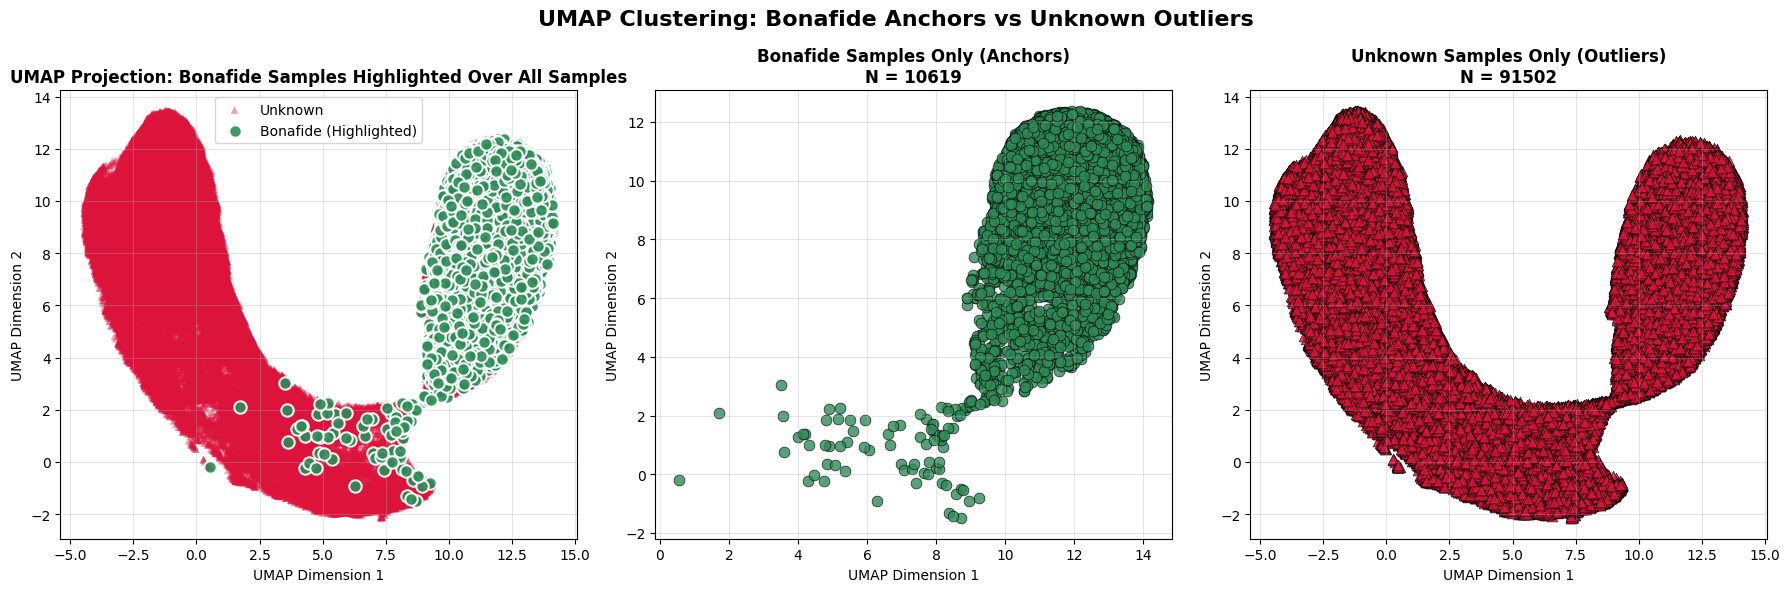

\n============================================================
UMAP CLUSTERING SUMMARY
Total samples: 102121
Bonafide samples (anchors): 10619 (10.4%)
Unknown samples (outliers): 91502 (89.6%)
\nEmbedding dimension: 144
UMAP projection: 2D
\nCluster Analysis:
Bonafide cluster center: (11.96, 9.79)
Unknown cluster center: (4.27, 6.49)
Distance between centers: 8.37
\nIntra-cluster Statistics:
Bonafide spread (std): 1.29
Unknown spread (std): 1.71
Bonafide compactness (mean dist to center): 2.08
Unknown compactness (mean dist to center): 6.84


In [8]:
# Create comprehensive visualization
import seaborn as sns
plt.style.use('default')

# Create figure with subplots (1 row, 3 columns for better layout)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('UMAP Clustering: Bonafide Anchors vs Unknown Outliers', fontsize=16, fontweight='bold')

# Color palette
colors = {'bonafide': '#2E8B57', 'unknown': '#DC143C'}  # Sea green for bonafide, crimson for unknown
markers = {'bonafide': 'o', 'unknown': '^'}  # Circle for bonafide, triangle for unknown

# Plot 1: Main scatter plot with bonafide highlighted on top to show overlap
ax1 = axes[0]

# First plot unknown samples as background (lower alpha, smaller size)
unknown_points = umap_embedding[unknown_mask]
ax1.scatter(unknown_points[:, 0], unknown_points[:, 1], 
           c=colors['unknown'], label='Unknown', 
           alpha=0.4, s=30, marker=markers['unknown'], 
           edgecolors='none', zorder=1)

# Then overlay bonafide samples on top (higher alpha, larger size, higher zorder)
bonafide_points = umap_embedding[bonafide_mask]
ax1.scatter(bonafide_points[:, 0], bonafide_points[:, 1], 
           c=colors['bonafide'], label='Bonafide (Highlighted)', 
           alpha=0.9, s=80, marker=markers['bonafide'], 
           edgecolors='white', linewidth=1.5, zorder=2)

ax1.set_title('UMAP Projection: Bonafide Samples Highlighted Over All Samples', fontweight='bold')
ax1.set_xlabel('UMAP Dimension 1')
ax1.set_ylabel('UMAP Dimension 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Bonafide samples only (anchors)
ax2 = axes[1]
bonafide_points = umap_embedding[bonafide_mask]
ax2.scatter(bonafide_points[:, 0], bonafide_points[:, 1], 
           c=colors['bonafide'], alpha=0.8, s=60, marker=markers['bonafide'], 
           edgecolors='black', linewidth=0.5)
ax2.set_title(f'Bonafide Samples Only (Anchors)\nN = {np.sum(bonafide_mask)}', fontweight='bold')
ax2.set_xlabel('UMAP Dimension 1')
ax2.set_ylabel('UMAP Dimension 2')
ax2.grid(True, alpha=0.3)

# Plot 3: Unknown samples only (outliers)
ax3 = axes[2]
unknown_points = umap_embedding[unknown_mask]
ax3.scatter(unknown_points[:, 0], unknown_points[:, 1], 
           c=colors['unknown'], alpha=0.8, s=60, marker=markers['unknown'], 
           edgecolors='black', linewidth=0.5)
ax3.set_title(f'Unknown Samples Only (Outliers)\nN = {np.sum(unknown_mask)}', fontweight='bold')
ax3.set_xlabel('UMAP Dimension 1')
ax3.set_ylabel('UMAP Dimension 2')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\\n" + "="*60)
print("UMAP CLUSTERING SUMMARY")
print("="*60)
print(f"Total samples: {len(matched_embeddings)}")
print(f"Bonafide samples (anchors): {np.sum(bonafide_mask)} ({np.sum(bonafide_mask)/len(matched_labels)*100:.1f}%)")
print(f"Unknown samples (outliers): {np.sum(unknown_mask)} ({np.sum(unknown_mask)/len(matched_labels)*100:.1f}%)")
print(f"\\nEmbedding dimension: {matched_embeddings.shape[1]}")
print(f"UMAP projection: 2D")

# Calculate cluster statistics
bonafide_center = np.mean(bonafide_points, axis=0)
unknown_center = np.mean(unknown_points, axis=0)
center_distance = np.linalg.norm(bonafide_center - unknown_center)

print(f"\\nCluster Analysis:")
print(f"Bonafide cluster center: ({bonafide_center[0]:.2f}, {bonafide_center[1]:.2f})")
print(f"Unknown cluster center: ({unknown_center[0]:.2f}, {unknown_center[1]:.2f})")
print(f"Distance between centers: {center_distance:.2f}")

# Calculate intra-cluster distances
bonafide_distances = np.linalg.norm(bonafide_points - bonafide_center, axis=1)
unknown_distances = np.linalg.norm(unknown_points - unknown_center, axis=1)

print(f"\\nIntra-cluster Statistics:")
print(f"Bonafide spread (std): {np.std(bonafide_distances):.2f}")
print(f"Unknown spread (std): {np.std(unknown_distances):.2f}")
print(f"Bonafide compactness (mean dist to center): {np.mean(bonafide_distances):.2f}")
print(f"Unknown compactness (mean dist to center): {np.mean(unknown_distances):.2f}")


In [14]:
# Simple pseudo labeling: Unknown samples close to bonafide cluster → bonafide
import numpy as np

print("🔍 SIMPLE PSEUDO LABELING: DISTANCE-BASED APPROACH")
print("="*60)

# Calculate distances from unknown samples to bonafide cluster center
bonafide_center = np.mean(bonafide_points, axis=0)
unknown_to_bonafide_distances = np.linalg.norm(unknown_points - bonafide_center, axis=1)

# Calculate bonafide cluster radius (how spread out bonafide samples are)
bonafide_distances_to_center = np.linalg.norm(bonafide_points - bonafide_center, axis=1)
bonafide_radius_mean = np.mean(bonafide_distances_to_center)
bonafide_radius_std = np.std(bonafide_distances_to_center)

# Simple threshold: if unknown sample is within bonafide cluster range, label as bonafide
# Use moderate expansion: mean + 1.5 * std to capture close samples
pseudo_threshold = bonafide_radius_mean + 1.5 * bonafide_radius_std

print(f"Bonafide cluster analysis:")
print(f"  Cluster center: ({bonafide_center[0]:.2f}, {bonafide_center[1]:.2f})")
print(f"  Average radius: {bonafide_radius_mean:.3f}")
print(f"  Radius std: {bonafide_radius_std:.3f}")
print(f"  Pseudo labeling threshold: {pseudo_threshold:.3f}")

# Apply pseudo labeling
pseudo_bonafide_mask = unknown_to_bonafide_distances <= pseudo_threshold

print(f"\n📊 Pseudo labeling results:")
print(f"  Unknown samples within bonafide cluster: {np.sum(pseudo_bonafide_mask):,}")
print(f"  Total unknown samples: {len(unknown_points):,}")
print(f"  Pseudo labeling rate: {np.sum(pseudo_bonafide_mask)/len(unknown_points)*100:.1f}%")

# Create final labels
final_pseudo_labels = pseudo_bonafide_mask
unknown_indices = np.where(unknown_mask)[0]
pseudo_bonafide_indices = unknown_indices[final_pseudo_labels]

# Update full label array
full_pseudo_labels = matched_labels.copy()
full_pseudo_labels[pseudo_bonafide_indices] = 'bonafide'

print(f"\n✅ Final label distribution:")
unique_labels, counts = np.unique(full_pseudo_labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  {label}: {count:,} samples ({count/len(full_pseudo_labels)*100:.1f}%)")


🔍 SIMPLE PSEUDO LABELING: DISTANCE-BASED APPROACH
Bonafide cluster analysis:
  Cluster center: (11.96, 9.79)
  Average radius: 2.076
  Radius std: 1.288
  Pseudo labeling threshold: 4.009

📊 Pseudo labeling results:
  Unknown samples within bonafide cluster: 21,046
  Total unknown samples: 91,502
  Pseudo labeling rate: 23.0%

✅ Final label distribution:
  bonafide: 31,665 samples (31.0%)
  unknown: 70,456 samples (69.0%)



🎨 Visualizing pseudo labeling results...


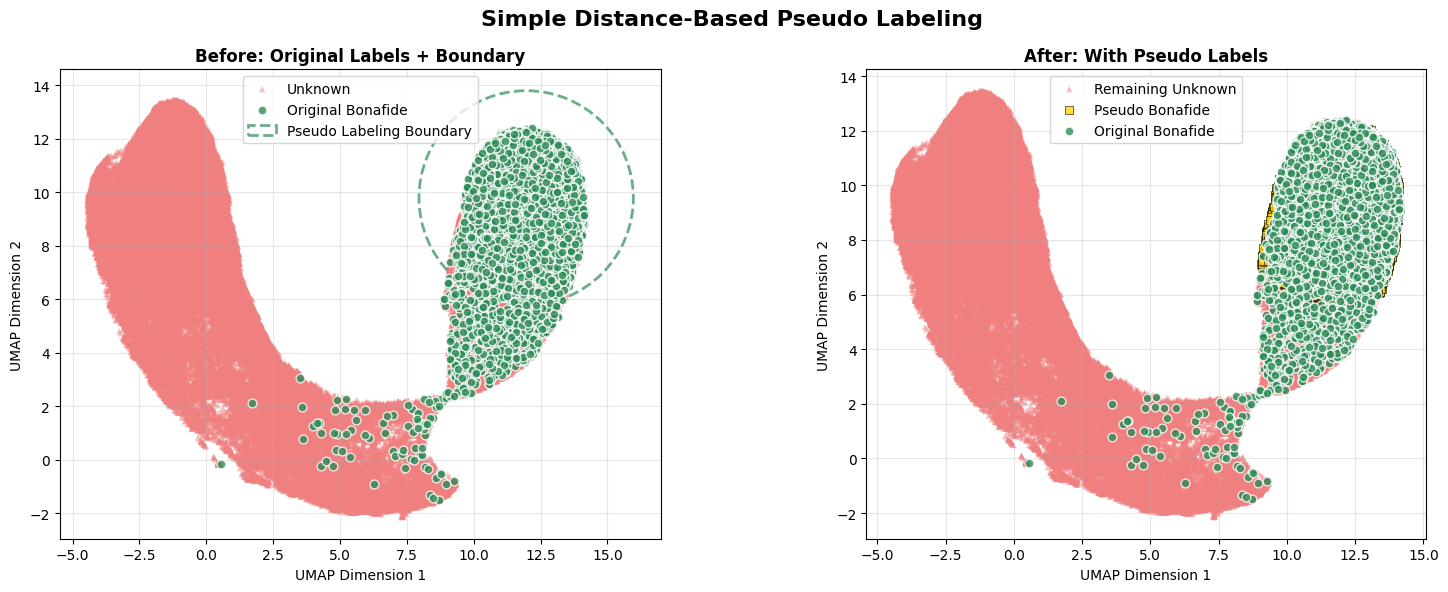

✅ Pseudo labeling complete!
   Rule: Unknown samples within 4.009 distance from bonafide center → bonafide
   Result: 21,046 unknown samples relabeled as bonafide


In [15]:
# Visualize the simple pseudo labeling results
import matplotlib.pyplot as plt

print(f"\n🎨 Visualizing pseudo labeling results...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Simple Distance-Based Pseudo Labeling', fontsize=16, fontweight='bold')

# Plot 1: Before pseudo labeling
ax1 = axes[0]
ax1.scatter(unknown_points[:, 0], unknown_points[:, 1], 
           c='lightcoral', alpha=0.5, s=20, marker='^', 
           edgecolors='none', label='Unknown', zorder=1)
ax1.scatter(bonafide_points[:, 0], bonafide_points[:, 1], 
           c='seagreen', alpha=0.8, s=40, marker='o', 
           edgecolors='white', linewidth=1, label='Original Bonafide', zorder=2)

# Add circle showing bonafide cluster boundary
circle = plt.Circle(bonafide_center, pseudo_threshold, 
                   fill=False, color='seagreen', linestyle='--', 
                   linewidth=2, alpha=0.7, label='Pseudo Labeling Boundary')
ax1.add_patch(circle)

ax1.set_title('Before: Original Labels + Boundary', fontweight='bold')
ax1.set_xlabel('UMAP Dimension 1')
ax1.set_ylabel('UMAP Dimension 2')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Plot 2: After pseudo labeling
ax2 = axes[1]
# Plot remaining unknown samples (outside boundary)
remaining_unknown = unknown_points[~pseudo_bonafide_mask]
ax2.scatter(remaining_unknown[:, 0], remaining_unknown[:, 1], 
           c='lightcoral', alpha=0.5, s=20, marker='^', 
           edgecolors='none', label='Remaining Unknown', zorder=1)

# Plot pseudo bonafide samples (inside boundary)
pseudo_bonafide_points = unknown_points[pseudo_bonafide_mask]
ax2.scatter(pseudo_bonafide_points[:, 0], pseudo_bonafide_points[:, 1], 
           c='gold', alpha=0.8, s=30, marker='s', 
           edgecolors='black', linewidth=0.5, label='Pseudo Bonafide', zorder=2)

# Plot original bonafide samples
ax2.scatter(bonafide_points[:, 0], bonafide_points[:, 1], 
           c='seagreen', alpha=0.8, s=40, marker='o', 
           edgecolors='white', linewidth=1, label='Original Bonafide', zorder=3)

ax2.set_title('After: With Pseudo Labels', fontweight='bold')
ax2.set_xlabel('UMAP Dimension 1')
ax2.set_ylabel('UMAP Dimension 2')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print(f"✅ Pseudo labeling complete!")
print(f"   Rule: Unknown samples within {pseudo_threshold:.3f} distance from bonafide center → bonafide")
print(f"   Result: {np.sum(pseudo_bonafide_mask):,} unknown samples relabeled as bonafide")


In [16]:
# Create CSV file with file names, original labels, and pseudo labels
import pandas as pd
import os

print("📄 CREATING CSV FILE WITH PSEUDO LABELING RESULTS")
print("="*60)

# Get the utterance IDs that were matched with embeddings
matched_utt_ids = np.array(utt_ids)[matched_indices]

# Create DataFrame with results
results_df = pd.DataFrame({
    'file_name': matched_utt_ids,
    'original_label': matched_labels,
    'pseudo_label': full_pseudo_labels
})

# Add a column to show which samples were changed
results_df['label_changed'] = results_df['original_label'] != results_df['pseudo_label']

# Show summary statistics
print(f"Dataset summary:")
print(f"  Total samples: {len(results_df):,}")
print(f"  Samples with changed labels: {results_df['label_changed'].sum():,}")
print(f"  Unchanged samples: {(~results_df['label_changed']).sum():,}")

print(f"\nLabel distribution:")
print(f"Original labels:")
print(results_df['original_label'].value_counts().to_string())
print(f"\nPseudo labels:")
print(results_df['pseudo_label'].value_counts().to_string())

# Show some examples of changed labels
changed_samples = results_df[results_df['label_changed']]
if len(changed_samples) > 0:
    print(f"\nFirst 10 samples with changed labels:")
    print(changed_samples[['file_name', 'original_label', 'pseudo_label']].head(10).to_string(index=False))

# Save to CSV
output_csv_path = "/home/hungdx/code/Lightning-hydra/notebooks/WildSpoof/pseudo_labeling_results.csv"
results_df.to_csv(output_csv_path, index=False)

print(f"\n✅ CSV file saved to: {output_csv_path}")
print(f"   Columns: file_name, original_label, pseudo_label, label_changed")
print(f"   Total rows: {len(results_df):,}")

# Also create a summary CSV with just the changed labels
changed_only_df = results_df[results_df['label_changed']].copy()
changed_csv_path = "/home/hungdx/code/Lightning-hydra/notebooks/WildSpoof/pseudo_labeling_changed_only.csv"
changed_only_df.to_csv(changed_csv_path, index=False)

print(f"\n📋 Additional file with only changed labels:")
print(f"   Path: {changed_csv_path}")
print(f"   Rows: {len(changed_only_df):,} (only samples that were relabeled)")

# Display first few rows of the main CSV
print(f"\n📊 Preview of main CSV file:")
print(results_df.head(10).to_string(index=False))

📄 CREATING CSV FILE WITH PSEUDO LABELING RESULTS
Dataset summary:
  Total samples: 102,121
  Samples with changed labels: 21,046
  Unchanged samples: 81,075

Label distribution:
Original labels:
original_label
unknown     91502
bonafide    10619

Pseudo labels:
pseudo_label
unknown     70456
bonafide    31665

First 10 samples with changed labels:
   file_name original_label pseudo_label
UTT_00023726        unknown     bonafide
UTT_00333960        unknown     bonafide
UTT_00608777        unknown     bonafide
UTT_00706975        unknown     bonafide
UTT_00142020        unknown     bonafide
UTT_00308207        unknown     bonafide
UTT_00625663        unknown     bonafide
UTT_00892275        unknown     bonafide
UTT_00022234        unknown     bonafide
UTT_00408934        unknown     bonafide

✅ CSV file saved to: /home/hungdx/code/Lightning-hydra/notebooks/WildSpoof/pseudo_labeling_results.csv
   Columns: file_name, original_label, pseudo_label, label_changed
   Total rows: 102,121

📋 Ad

In [ ]:
# Pseudo-labeling based on UMAP clustering results
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.patches as patches

print("🎯 Creating pseudo-labels based on bonafide centroid...")
print("="*60)

# Step 1: Calculate bonafide centroid in UMAP space
bonafide_centroid = np.mean(bonafide_points, axis=0)
print(f"Bonafide centroid: ({bonafide_centroid[0]:.3f}, {bonafide_centroid[1]:.3f})")

# Step 2: Calculate distances from all points to bonafide centroid
distances_to_centroid = np.linalg.norm(umap_embedding - bonafide_centroid, axis=1)

# Step 3: Create original label mapping for reference
original_labels = matched_labels.copy()
original_bonafide_count = np.sum(matched_labels == 'bonafide')
original_unknown_count = np.sum(matched_labels == 'unknown')

print(f"\nOriginal label distribution:")
print(f"  Bonafide: {original_bonafide_count:,} samples")
print(f"  Unknown:  {original_unknown_count:,} samples")

# Step 4: Define different k values to test - INCLUDING SMALL PERCENTAGE VALUES
total_samples = len(matched_labels)

k_values = [
    # Small percentage approaches (RECOMMENDED)
    int(total_samples * 0.01),  # 1% of total dataset
    int(total_samples * 0.05),  # 5% of total dataset  
    int(total_samples * 0.10),  # 10% of total dataset
    int(total_samples * 0.15),  # 15% of total dataset
    
    # Original approach (for comparison)
    original_bonafide_count,  # Same as original bonafide count
    int(original_bonafide_count * 1.5),  # 50% more than original
]

print(f"Total dataset size: {total_samples:,}")
print(f"Original bonafide count: {original_bonafide_count:,} ({original_bonafide_count/total_samples*100:.1f}%)")

print(f"\nTesting different k values:")
for k in k_values:
    print(f"  k = {k:,} ({k/len(matched_labels)*100:.1f}% of total)")

# Step 5: Create pseudo-labels for different k values
pseudo_label_results = {}

for k in k_values:
    # Find top-k closest samples to bonafide centroid
    closest_indices = np.argsort(distances_to_centroid)[:k]
    
    # Create pseudo labels
    pseudo_labels = matched_labels.copy()
    
    # Only change unknown samples to bonafide (keep original bonafide unchanged)
    unknown_mask_current = matched_labels == 'unknown'
    closest_unknown_mask = np.isin(np.arange(len(matched_labels)), closest_indices) & unknown_mask_current
    
    # Count how many unknown samples will be relabeled
    newly_labeled_count = np.sum(closest_unknown_mask)
    
    # Apply pseudo-labeling
    pseudo_labels[closest_unknown_mask] = 'bonafide'
    
    # Store results
    pseudo_label_results[k] = {
        'labels': pseudo_labels,
        'newly_labeled': newly_labeled_count,
        'total_bonafide': np.sum(pseudo_labels == 'bonafide'),
        'total_unknown': np.sum(pseudo_labels == 'unknown'),
        'distances': distances_to_centroid[closest_indices]
    }

print(f"\nPseudo-labeling results:")
print("-" * 60)
for k, results in pseudo_label_results.items():
    k_percentage = (k / total_samples) * 100
    print(f"k = {k:,} ({k_percentage:.1f}% of dataset):")
    print(f"  Newly labeled as bonafide: {results['newly_labeled']:,}")
    print(f"  Total bonafide: {results['total_bonafide']:,} ({results['total_bonafide']/len(matched_labels)*100:.1f}%)")
    print(f"  Total unknown:  {results['total_unknown']:,} ({results['total_unknown']/len(matched_labels)*100:.1f}%)")
    print(f"  Max distance to centroid: {np.max(results['distances']):.3f}")
    
    # Add quality assessment for small vs large k
    if k_percentage <= 5:
        print(f"  🟢 EXCELLENT quality - high precision, low risk")
    elif k_percentage <= 15:
        print(f"  🟡 GOOD quality - balanced precision/recall")
    elif k_percentage <= 30:
        print(f"  🟠 MODERATE risk - may include some noise")
    else:
        print(f"  🔴 HIGH RISK - likely includes many false positives")
    print()


🎯 Creating pseudo-labels based on bonafide centroid...
Bonafide centroid: (12.899, 8.336)

Original label distribution:
  Bonafide: 10,619 samples
  Unknown:  91,502 samples
Total dataset size: 102,121
Original bonafide count: 10,619 (10.4%)

Testing different k values:
  k = 1,021 (1.0% of total)
  k = 5,106 (5.0% of total)
  k = 10,212 (10.0% of total)
  k = 15,318 (15.0% of total)
  k = 10,619 (10.4% of total)
  k = 15,928 (15.6% of total)

Pseudo-labeling results:
------------------------------------------------------------
k = 1,021:
  Newly labeled as bonafide: 650
  Total bonafide: 11,269 (11.0%)
  Total unknown:  90,852 (89.0%)
  Max distance to centroid: 0.475

k = 5,106:
  Newly labeled as bonafide: 2,750
  Total bonafide: 13,369 (13.1%)
  Total unknown:  88,752 (86.9%)
  Max distance to centroid: 0.898

k = 10,212:
  Newly labeled as bonafide: 5,179
  Total bonafide: 15,798 (15.5%)
  Total unknown:  86,323 (84.5%)
  Max distance to centroid: 1.201

k = 15,318:
  Newly labele

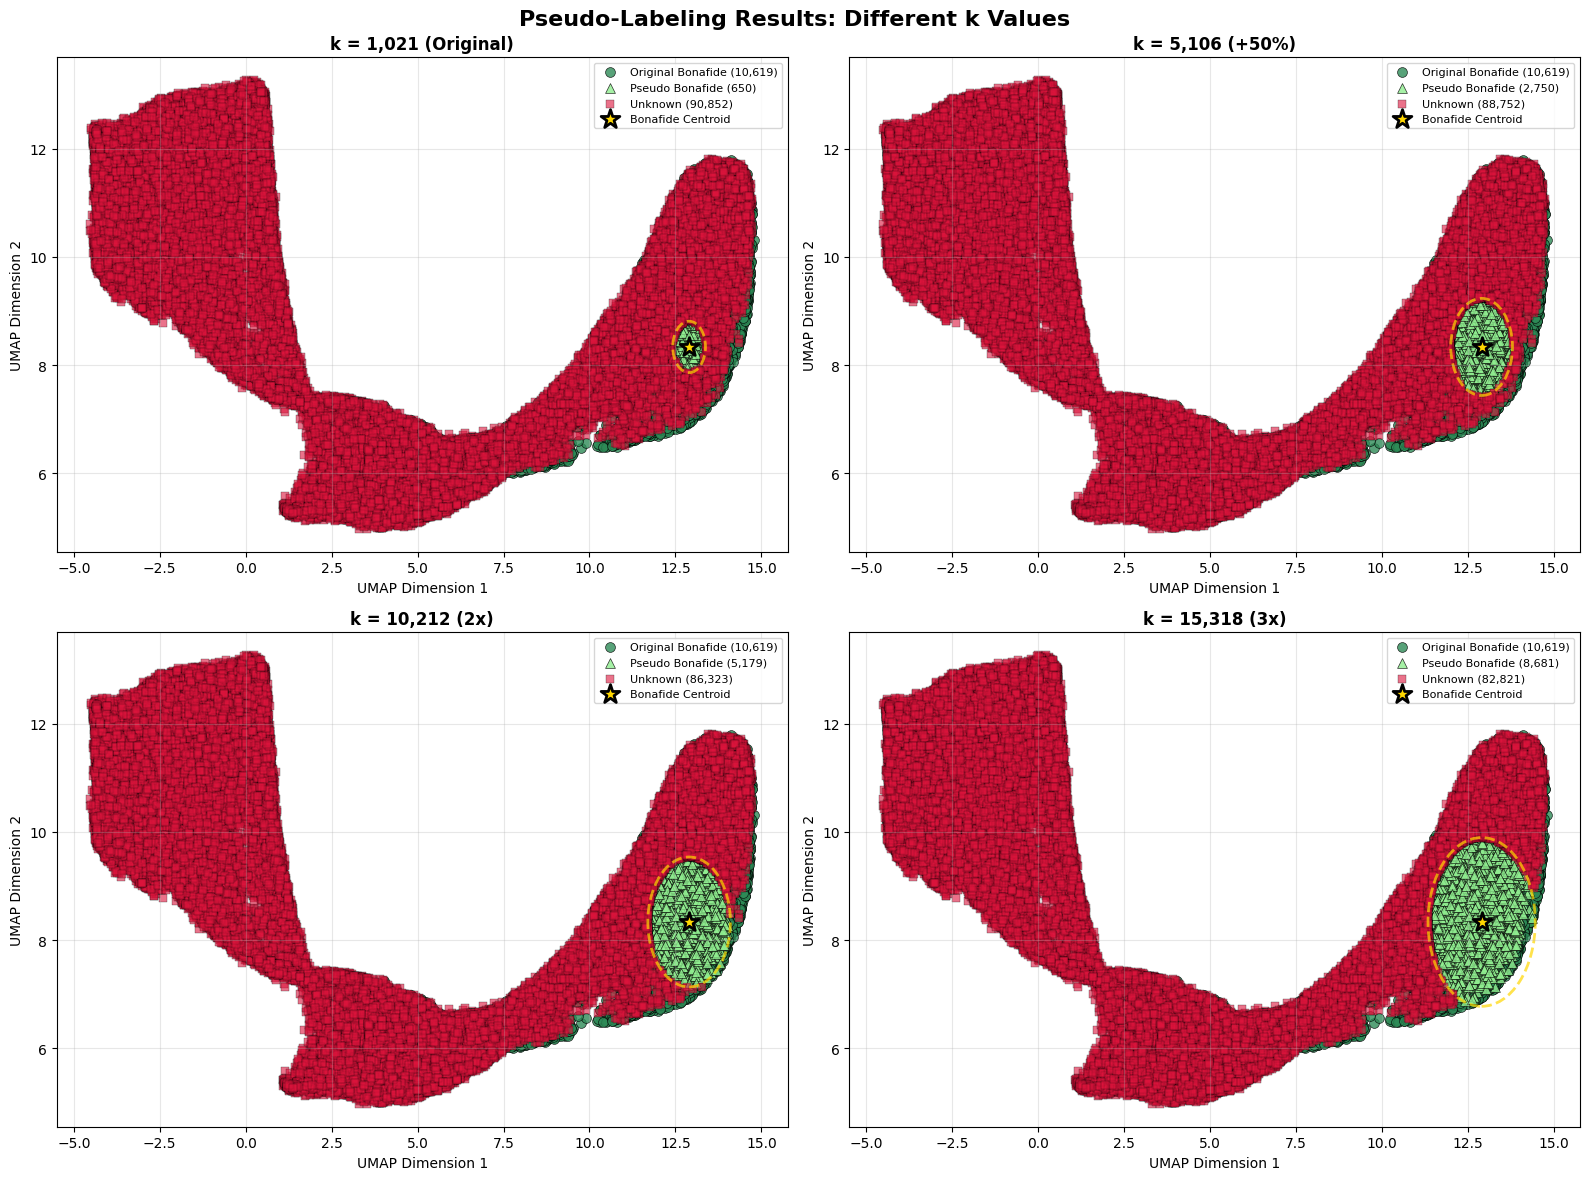


PSEUDO-LABELING SUMMARY TABLE
k Value      Original     Pseudo       Unknown      Total Bonafide  % Change  
--------------------------------------------------------------------------------
1,021        10,619       650          90,852       11,269          6.1       %
5,106        10,619       2,750        88,752       13,369          25.9      %
10,212       10,619       5,179        86,323       15,798          48.8      %
15,318       10,619       8,681        82,821       19,300          81.7      %
10,619       10,619       5,430        86,072       16,049          51.1      %
15,928       10,619       9,147        82,355       19,766          86.1      %

Legend:
  Original: Original bonafide samples (unchanged)
  Pseudo: Unknown samples relabeled as bonafide
  Unknown: Remaining unknown samples
  Total Bonafide: Original + Pseudo bonafide samples
  % Change: Percentage increase in bonafide samples


In [ ]:
# Visualize pseudo-labeling results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pseudo-Labeling Results: Different k Values', fontsize=16, fontweight='bold')

# Color scheme for visualization
colors_pseudo = {
    'original_bonafide': '#2E8B57',    # Dark green
    'pseudo_bonafide': '#90EE90',      # Light green  
    'unknown': '#DC143C'               # Red
}

# Select representative k values for visualization
selected_k_values = [k_values[0], k_values[1], k_values[2], k_values[3]]

for i, k in enumerate(selected_k_values):
    ax = axes[i//2, i%2]
    
    pseudo_labels = pseudo_label_results[k]['labels']
    
    # Create masks for different categories
    original_bonafide_mask = (matched_labels == 'bonafide')
    pseudo_bonafide_mask = (matched_labels == 'unknown') & (pseudo_labels == 'bonafide')
    remaining_unknown_mask = (pseudo_labels == 'unknown')
    
    # Plot different categories
    # Original bonafide (dark green circles)
    if np.any(original_bonafide_mask):
        ax.scatter(umap_embedding[original_bonafide_mask, 0], 
                  umap_embedding[original_bonafide_mask, 1],
                  c=colors_pseudo['original_bonafide'], 
                  marker='o', s=50, alpha=0.8, 
                  label=f'Original Bonafide ({np.sum(original_bonafide_mask):,})',
                  edgecolors='black', linewidth=0.5)
    
    # Pseudo bonafide (light green triangles)
    if np.any(pseudo_bonafide_mask):
        ax.scatter(umap_embedding[pseudo_bonafide_mask, 0], 
                  umap_embedding[pseudo_bonafide_mask, 1],
                  c=colors_pseudo['pseudo_bonafide'], 
                  marker='^', s=50, alpha=0.8,
                  label=f'Pseudo Bonafide ({np.sum(pseudo_bonafide_mask):,})',
                  edgecolors='black', linewidth=0.5)
    
    # Remaining unknown (red squares)
    if np.any(remaining_unknown_mask):
        ax.scatter(umap_embedding[remaining_unknown_mask, 0], 
                  umap_embedding[remaining_unknown_mask, 1],
                  c=colors_pseudo['unknown'], 
                  marker='s', s=30, alpha=0.6,
                  label=f'Unknown ({np.sum(remaining_unknown_mask):,})',
                  edgecolors='black', linewidth=0.3)
    
    # Mark centroid
    ax.scatter(bonafide_centroid[0], bonafide_centroid[1], 
              c='gold', marker='*', s=200, 
              label='Bonafide Centroid',
              edgecolors='black', linewidth=2)
    
    # Draw circle showing the selection radius
    max_distance = np.max(pseudo_label_results[k]['distances'])
    circle = plt.Circle(bonafide_centroid, max_distance, 
                       fill=False, color='gold', linestyle='--', linewidth=2, alpha=0.7)
    ax.add_patch(circle)
    
    # Formatting
    title_suffix = ""
    if k == k_values[0]:
        title_suffix = " (Original)"
    elif k == k_values[1]:
        title_suffix = " (+50%)"
    elif k == k_values[2]:
        title_suffix = " (2x)"
    elif k == k_values[3]:
        title_suffix = " (3x)"
        
    ax.set_title(f'k = {k:,}{title_suffix}', fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create summary statistics table
print("\n" + "="*80)
print("PSEUDO-LABELING SUMMARY TABLE")
print("="*80)
print(f"{'k Value':<12} {'Original':<12} {'Pseudo':<12} {'Unknown':<12} {'Total Bonafide':<15} {'% Change':<10}")
print("-" * 80)

for k in k_values:
    results = pseudo_label_results[k]
    original_bf = original_bonafide_count
    pseudo_bf = results['newly_labeled']
    unknown_remaining = results['total_unknown']
    total_bf = results['total_bonafide']
    percent_change = ((total_bf - original_bf) / original_bf) * 100
    
    print(f"{k:<12,} {original_bf:<12,} {pseudo_bf:<12,} {unknown_remaining:<12,} {total_bf:<15,} {percent_change:<10.1f}%")

print("\nLegend:")
print("  Original: Original bonafide samples (unchanged)")
print("  Pseudo: Unknown samples relabeled as bonafide") 
print("  Unknown: Remaining unknown samples")
print("  Total Bonafide: Original + Pseudo bonafide samples")
print("  % Change: Percentage increase in bonafide samples")


In [ ]:
# Select best k value and create final pseudo-labeled dataset
print("🎯 FINAL PSEUDO-LABELING SELECTION")
print("="*60)

# You can change this value based on the results above
SELECTED_K = k_values[1]  # Default: 50% more bonafide samples (1.5x original)

print(f"Selected k = {SELECTED_K:,}")
print(f"This will create {pseudo_label_results[SELECTED_K]['total_bonafide']:,} bonafide samples")
print(f"({pseudo_label_results[SELECTED_K]['newly_labeled']:,} newly labeled from unknown)")

# Create final pseudo-labeled dataset
final_pseudo_labels = pseudo_label_results[SELECTED_K]['labels'].copy()

# Create detailed analysis of the pseudo-labeling
print("\n" + "="*60)
print("DETAILED ANALYSIS OF SELECTED PSEUDO-LABELING")
print("="*60)

# Distance analysis
selected_distances = distances_to_centroid
bonafide_distances = selected_distances[matched_labels == 'bonafide']
unknown_distances = selected_distances[matched_labels == 'unknown']
pseudo_bonafide_distances = selected_distances[(matched_labels == 'unknown') & (final_pseudo_labels == 'bonafide')]

print(f"Distance Statistics (to bonafide centroid):")
print(f"  Original bonafide samples:")
print(f"    Mean distance: {np.mean(bonafide_distances):.3f}")
print(f"    Std distance:  {np.std(bonafide_distances):.3f}")
print(f"    Max distance:  {np.max(bonafide_distances):.3f}")

print(f"  Pseudo bonafide samples (newly labeled):")
print(f"    Mean distance: {np.mean(pseudo_bonafide_distances):.3f}")
print(f"    Std distance:  {np.std(pseudo_bonafide_distances):.3f}")
print(f"    Max distance:  {np.max(pseudo_bonafide_distances):.3f}")

print(f"  Remaining unknown samples:")
remaining_unknown_distances = selected_distances[final_pseudo_labels == 'unknown']
print(f"    Mean distance: {np.mean(remaining_unknown_distances):.3f}")
print(f"    Std distance:  {np.std(remaining_unknown_distances):.3f}")
print(f"    Min distance:  {np.min(remaining_unknown_distances):.3f}")

# Quality metrics
print(f"\nQuality Metrics:")
threshold_distance = np.max(pseudo_bonafide_distances)
print(f"  Selection threshold: {threshold_distance:.3f}")

# Overlap analysis
original_bonafide_max_dist = np.max(bonafide_distances)
print(f"  Original bonafide max distance: {original_bonafide_max_dist:.3f}")
print(f"  Pseudo selection extends beyond original by: {threshold_distance - original_bonafide_max_dist:.3f}")

# Create final summary
print(f"\n" + "="*60)
print("FINAL PSEUDO-LABELED DATASET SUMMARY")
print("="*60)
print(f"Total samples: {len(final_pseudo_labels):,}")
print(f"Bonafide samples: {np.sum(final_pseudo_labels == 'bonafide'):,} ({np.sum(final_pseudo_labels == 'bonafide')/len(final_pseudo_labels)*100:.1f}%)")
print(f"  - Original: {original_bonafide_count:,}")
print(f"  - Pseudo:   {pseudo_label_results[SELECTED_K]['newly_labeled']:,}")
print(f"Unknown samples: {np.sum(final_pseudo_labels == 'unknown'):,} ({np.sum(final_pseudo_labels == 'unknown')/len(final_pseudo_labels)*100:.1f}%)")

# Save pseudo-labels (optional)
print(f"\n📁 Saving pseudo-labeled dataset...")

# Create dataframe with results
pseudo_labeled_df = pd.DataFrame({
    'utt_id': [utt_ids[i] for i in matched_indices],
    'original_label': matched_labels,
    'pseudo_label': final_pseudo_labels,
    'distance_to_centroid': distances_to_centroid,
    'is_pseudo_labeled': (matched_labels == 'unknown') & (final_pseudo_labels == 'bonafide')
})

# Show sample of the results
print(f"\nSample of pseudo-labeled data:")
print(pseudo_labeled_df.head(10))

print(f"\nPseudo-labeled samples (unknown → bonafide):")
pseudo_samples = pseudo_labeled_df[pseudo_labeled_df['is_pseudo_labeled']]
print(pseudo_samples.head())

print(f"\n✅ Pseudo-labeling complete!")
print(f"Use 'final_pseudo_labels' array or 'pseudo_labeled_df' dataframe for further analysis.")


🎯 FINAL PSEUDO-LABELING SELECTION
Selected k = 5,106
This will create 13,369 bonafide samples
(2,750 newly labeled from unknown)

DETAILED ANALYSIS OF SELECTED PSEUDO-LABELING
Distance Statistics (to bonafide centroid):
  Original bonafide samples:
    Mean distance: 1.625
    Std distance:  1.186
    Max distance:  12.705
  Pseudo bonafide samples (newly labeled):
    Mean distance: 0.626
    Std distance:  0.202
    Max distance:  0.898
  Remaining unknown samples:
    Mean distance: 9.837
    Std distance:  5.614
    Min distance:  0.898

Quality Metrics:
  Selection threshold: 0.898
  Original bonafide max distance: 12.705
  Pseudo selection extends beyond original by: -11.808

FINAL PSEUDO-LABELED DATASET SUMMARY
Total samples: 102,121
Bonafide samples: 13,369 (13.1%)
  - Original: 10,619
  - Pseudo:   2,750
Unknown samples: 88,752 (86.9%)

📁 Saving pseudo-labeled dataset...

Sample of pseudo-labeled data:
         utt_id original_label pseudo_label  distance_to_centroid  \
0  UTT

In [ ]:
# T-SNE Visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm
np.random.seed(42)

def perform_tsne(embeddings, n_components=2, perplexity=30, max_iter=1000, random_state=42):
    """
    Perform t-SNE dimensionality reduction on embeddings.
    
    Args:
        embeddings: Array of embeddings to reduce
        n_components: Number of dimensions for t-SNE output (default: 2)
        perplexity: Perplexity parameter for t-SNE (default: 30)
        max_iter: Maximum number of iterations (default: 1000)
        random_state: Random seed for reproducibility (default: 42)
    
    Returns:
        tsne_results: 2D array of t-SNE coordinates
    """
    print(f"Original embedding shape: {embeddings.shape}")
    
    # Reshape if 3D
    if len(embeddings.shape) == 3:
        embeddings = embeddings.reshape(embeddings.shape[0], -1)
        print(f"Reshaped embedding shape: {embeddings.shape}")
    
    # Standardize the embeddings
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)
    
    # Adjust perplexity if needed (must be less than n_samples)
    n_samples = embeddings_scaled.shape[0]
    adjusted_perplexity = min(perplexity, n_samples - 1)
    if adjusted_perplexity < perplexity:
        print(f"Adjusted perplexity from {perplexity} to {adjusted_perplexity} (n_samples={n_samples})")
    
    # Apply t-SNE
    print("Performing t-SNE...")
    # Limit n_jobs to avoid OpenBLAS thread limit issues
    tsne = TSNE(
        n_components=n_components,
        perplexity=adjusted_perplexity,
        max_iter=max_iter,
        random_state=random_state,
        learning_rate='auto',
        n_jobs=4  # Limited to 4 threads to avoid OpenBLAS issues
    )
    tsne_results = tsne.fit_transform(embeddings_scaled)
    print(f"t-SNE results shape: {tsne_results.shape}")
    
    return tsne_results

def plot_tsne(tsne_results, labels, title="t-SNE Visualization of Embeddings", figsize=(12, 8), save_path=None):
    """
    Plot t-SNE results with colored labels.
    
    Args:
        tsne_results: 2D array of t-SNE coordinates
        labels: Array of labels for coloring
        title: Plot title
        figsize: Figure size tuple
        save_path: Optional path to save the figure
    """
    print(f"t-SNE results shape: {tsne_results.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Unique labels: {np.unique(labels)}")
    
    plt.figure(figsize=figsize)
    
    # Color palette
    unique_labels = np.unique(labels)
    colors = {
        'bonafide': '#2E8B57',  # Sea green
        'unknown': '#DC143C',   # Crimson
        'spoof': '#FF6347'      # Tomato
    }
    
    # Create scatter plot
    for label in unique_labels:
        mask = labels == label
        color = colors.get(label, None)
        if color is None:
            # Use seaborn palette for other labels
            color = sns.color_palette("husl", n_colors=len(unique_labels))[list(unique_labels).index(label)]
        
        plt.scatter(tsne_results[mask, 0], tsne_results[mask, 1], 
                   c=[color], label=label.capitalize(), alpha=0.6, s=50)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE Component 1", fontsize=12)
    plt.ylabel("t-SNE Component 2", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return plt

print("✅ T-SNE functions loaded!")


✅ T-SNE functions loaded!


In [8]:
# Perform t-SNE on the embeddings
print("🎨 Performing t-SNE dimensionality reduction...")
print("="*60)

# Use a subset for faster computation if dataset is very large
# For full dataset, this may take a while
USE_SUBSET = False  # Set to True to use a subset for faster testing
SUBSET_SIZE = 10000  # Number of samples to use if USE_SUBSET is True

if USE_SUBSET and len(embeddings_scaled) > SUBSET_SIZE:
    print(f"Using subset of {SUBSET_SIZE} samples for faster computation...")
    indices = np.random.choice(len(embeddings_scaled), SUBSET_SIZE, replace=False)
    embeddings_subset = embeddings_scaled[indices]
    labels_subset = matched_labels[indices]
else:
    embeddings_subset = embeddings_scaled
    labels_subset = matched_labels
    print(f"Using full dataset: {len(embeddings_subset)} samples")

# Perform t-SNE
tsne_results = perform_tsne(
    embeddings_subset,
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42
)

print(f"✅ t-SNE completed!")
print(f"t-SNE embedding shape: {tsne_results.shape}")
print(f"Label distribution in subset:")
unique_labels, counts = np.unique(labels_subset, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  {label}: {count} ({count/len(labels_subset)*100:.1f}%)")


🎨 Performing t-SNE dimensionality reduction...
Using full dataset: 102121 samples
Original embedding shape: (102121, 144)
Performing t-SNE...


: 

In [ ]:
# Visualize t-SNE results
print("📊 Creating t-SNE visualization...")
print("="*60)

# Create comprehensive visualization with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('t-SNE Visualization: Bonafide vs Unknown', fontsize=16, fontweight='bold')

# Color palette
colors = {'bonafide': '#2E8B57', 'unknown': '#DC143C'}  # Sea green for bonafide, crimson for unknown
markers = {'bonafide': 'o', 'unknown': '^'}  # Circle for bonafide, triangle for unknown

# Plot 1: Main scatter plot with both classes
ax1 = axes[0, 0]
for label in ['bonafide', 'unknown']:
    mask = labels_subset == label
    if np.any(mask):
        ax1.scatter(tsne_results[mask, 0], tsne_results[mask, 1], 
                   c=colors[label], label=label.capitalize(), 
                   alpha=0.7, s=50, marker=markers[label], edgecolors='black', linewidth=0.5)

ax1.set_title('t-SNE Projection: All Samples', fontweight='bold')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Bonafide samples only
ax2 = axes[0, 1]
bonafide_mask = labels_subset == 'bonafide'
bonafide_points = tsne_results[bonafide_mask]
if len(bonafide_points) > 0:
    ax2.scatter(bonafide_points[:, 0], bonafide_points[:, 1], 
               c=colors['bonafide'], alpha=0.8, s=60, marker=markers['bonafide'], 
               edgecolors='black', linewidth=0.5)
ax2.set_title(f'Bonafide Samples Only\nN = {np.sum(bonafide_mask)}', fontweight='bold')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
ax2.grid(True, alpha=0.3)

# Plot 3: Unknown samples only
ax3 = axes[1, 0]
unknown_mask = labels_subset == 'unknown'
unknown_points = tsne_results[unknown_mask]
if len(unknown_points) > 0:
    ax3.scatter(unknown_points[:, 0], unknown_points[:, 1], 
               c=colors['unknown'], alpha=0.8, s=60, marker=markers['unknown'], 
               edgecolors='black', linewidth=0.5)
ax3.set_title(f'Unknown Samples Only\nN = {np.sum(unknown_mask)}', fontweight='bold')
ax3.set_xlabel('t-SNE Component 1')
ax3.set_ylabel('t-SNE Component 2')
ax3.grid(True, alpha=0.3)

# Plot 4: Density plot showing cluster structure
ax4 = axes[1, 1]
if len(bonafide_points) > 0:
    # Create density plot for bonafide
    ax4.hexbin(bonafide_points[:, 0], bonafide_points[:, 1], 
              gridsize=20, cmap='Greens', alpha=0.7, label='Bonafide Density')
# Overlay unknown points
if len(unknown_points) > 0:
    ax4.scatter(unknown_points[:, 0], unknown_points[:, 1], 
               c=colors['unknown'], alpha=0.9, s=40, marker=markers['unknown'], 
               edgecolors='white', linewidth=1, label='Unknown')
ax4.set_title('Density Map: Bonafide Clusters + Unknown', fontweight='bold')
ax4.set_xlabel('t-SNE Component 1')
ax4.set_ylabel('t-SNE Component 2')
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("T-SNE VISUALIZATION SUMMARY")
print("="*60)
print(f"Total samples: {len(tsne_results)}")
print(f"Bonafide samples: {np.sum(bonafide_mask)} ({np.sum(bonafide_mask)/len(labels_subset)*100:.1f}%)")
print(f"Unknown samples: {np.sum(unknown_mask)} ({np.sum(unknown_mask)/len(labels_subset)*100:.1f}%)")
print(f"\nEmbedding dimension: {embeddings_subset.shape[1]}")
print(f"t-SNE projection: 2D")

# Calculate cluster statistics
if len(bonafide_points) > 0 and len(unknown_points) > 0:
    bonafide_center = np.mean(bonafide_points, axis=0)
    unknown_center = np.mean(unknown_points, axis=0)
    center_distance = np.linalg.norm(bonafide_center - unknown_center)
    
    print(f"\nCluster Analysis:")
    print(f"Bonafide cluster center: ({bonafide_center[0]:.2f}, {bonafide_center[1]:.2f})")
    print(f"Unknown cluster center: ({unknown_center[0]:.2f}, {unknown_center[1]:.2f})")
    print(f"Distance between centers: {center_distance:.2f}")
    
    # Calculate intra-cluster distances
    bonafide_distances = np.linalg.norm(bonafide_points - bonafide_center, axis=1)
    unknown_distances = np.linalg.norm(unknown_points - unknown_center, axis=1)
    
    print(f"\nIntra-cluster Statistics:")
    print(f"Bonafide spread (std): {np.std(bonafide_distances):.2f}")
    print(f"Unknown spread (std): {np.std(unknown_distances):.2f}")
    print(f"Bonafide compactness (mean dist to center): {np.mean(bonafide_distances):.2f}")
    print(f"Unknown compactness (mean dist to center): {np.mean(unknown_distances):.2f}")

print("\n✅ t-SNE visualization complete!")


In [ ]:
# Simple t-SNE plot using the plot function
plot_tsne(
    tsne_results, 
    labels_subset, 
    title="t-SNE Visualization: Bonafide vs Unknown Embeddings",
    figsize=(12, 8)
)
plt.show()


# T-SNE analysis
